## Tugas besar **3**

Downloadlah  <a href="https://drive.google.com/file/d/1gz_t3UHzBzHN8__19-eCs3JewH8n5ohl/view">vgsales.csv</a>

# Soal 1: Baca data vgsales

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('vgsales.csv')
display(df.head())

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Expected Output:
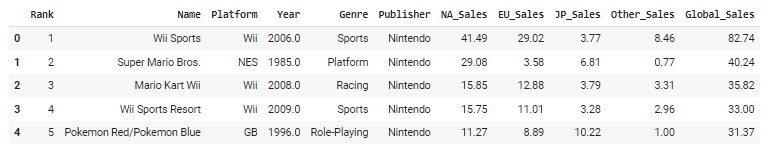

<h2>Soal 2: Preparing Data</h2>

Manipulasikanlah data tersebut dengan menggroupkan berdasarkan Genre, kemudian ambil rata2 penjualan untuk setiap Region Kecuali Global_Sales berdasarkan kategori Genre.

In [3]:
# Manipulasi data: group by Genre dan ambil rata-rata region (kecuali Global_Sales)
df_genre = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].mean()
display(df_genre)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,0.264726,0.158323,0.048236,0.056508
Adventure,0.082271,0.049868,0.040490,0.013072
Fighting,0.263667,0.119481,0.103007,0.043255
Misc,0.235906,0.124198,0.061967,0.043312
Platform,0.504571,0.227573,0.147596,0.058228
Puzzle,0.212680,0.087251,0.098471,0.021564
Racing,0.287766,0.190865,0.045388,0.061865
Role-Playing,0.219946,0.126384,0.236767,0.040060
Shooter,0.444733,0.239137,0.029221,0.078389


Expected Output:

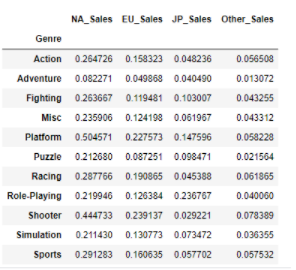

Soal 3: Tranformasikan data tersebut,dengan harapan saat divisualisasi  NA_Sales,EU_Sales,JP_Sales dan Other_Sales ada di sumbu-x

In [13]:
df_melted = df_genre.reset_index().melt(id_vars='Genre', var_name='Region', value_name='Mean_Sales')
display(df_melted)

,Genre,Region,Mean_Sales
0,Action,NA_Sales,0.264726
1,Adventure,NA_Sales,0.082271
2,Fighting,NA_Sales,0.263667
3,Misc,NA_Sales,0.235906
4,Platform,NA_Sales,0.504571
5,Puzzle,NA_Sales,0.212680
6,Racing,NA_Sales,0.287766
7,Role-Playing,NA_Sales,0.219946
8,Shooter,NA_Sales,0.444733
9,Simulation,NA_Sales,0.211430


Expected Output:

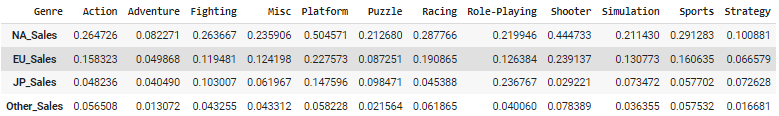

---

<h2>Soal 4: Perbandingan Kuantitatif Barplot - Grouping Visualisasi Dengan Barplot</h2>
1. Visualisasikan gambar yang tadi kamu manipulasi, untuk mengjasilkan visualisasi seperti di bawah ini
2. Tuliskan kesimpulan yang didapat dari visualisasi tersebut

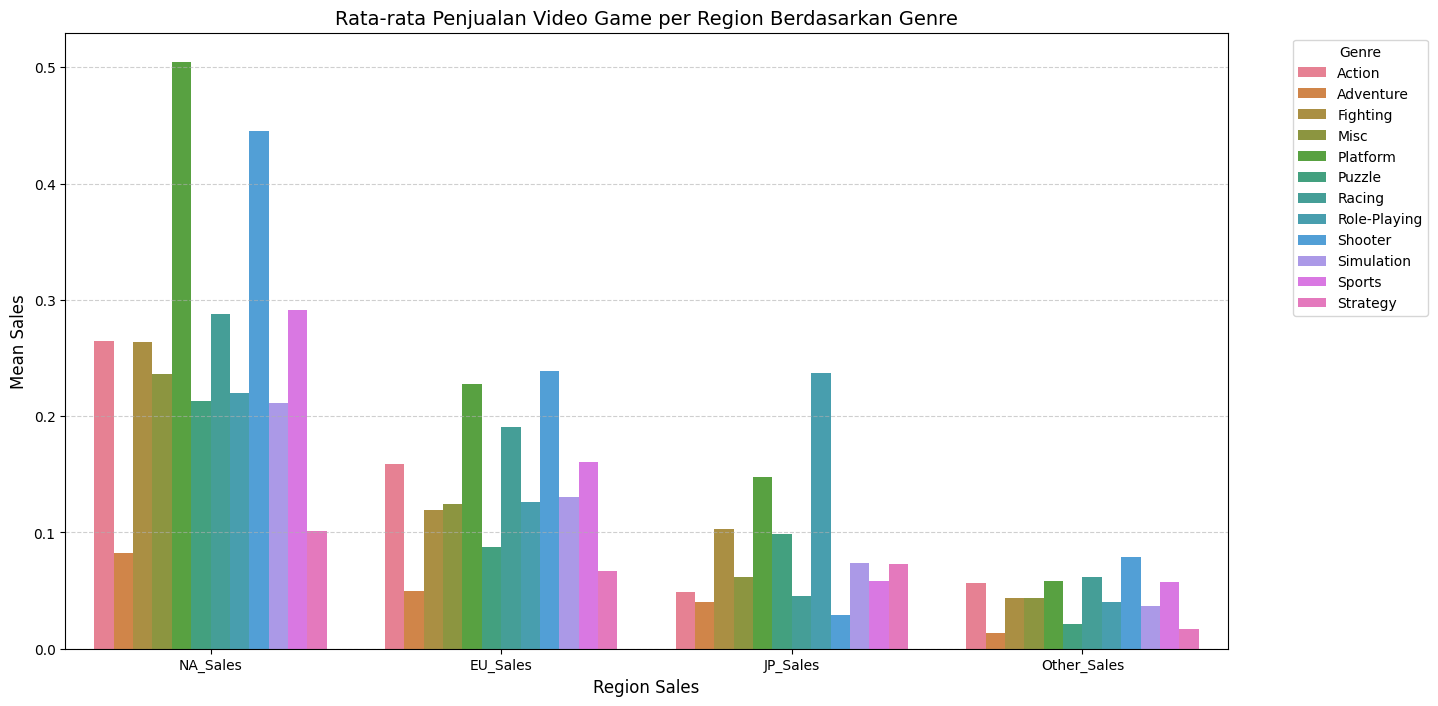

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisasi Grouping Barplot: x=Region, y=Mean_Sales
plt.figure(figsize=(15, 8))
sns.barplot(data=df_melted, x='Region', y='Mean_Sales', hue='Genre')

plt.title('Rata-rata Penjualan Video Game per Region Berdasarkan Genre', fontsize=14)
plt.ylabel('Mean Sales', fontsize=12)
plt.xlabel('Region Sales', fontsize=12)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Expected Output(abaikan warna pada grafik):
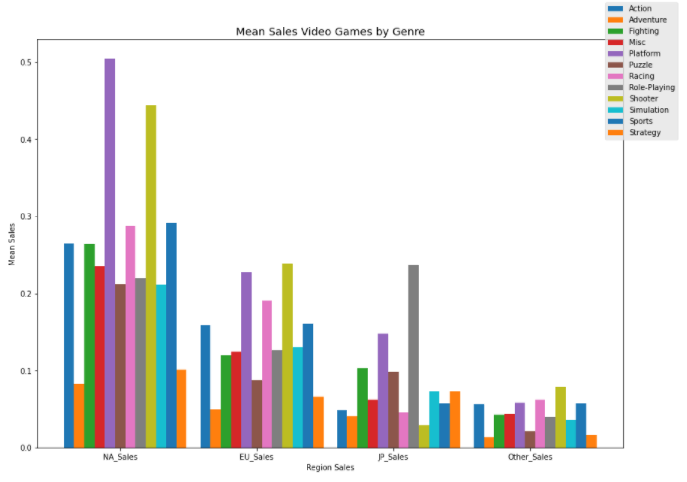


Kesimpulan:  
1. Wilayah Amerika Utara (NA_Sales) secara konsisten menunjukkan rata-rata penjualan tertinggi di hampir seluruh genre dibandingkan wilayah lainnya.
2. Genre Platform dan Shooter merupakan genre yang paling mendominasi di wilayah Amerika Utara dan Eropa.
3. Di wilayah Jepang (JP_Sales), genre Role-Playing jauh lebih populer dan memiliki angka penjualan rata-rata tertinggi dibandingkan genre lainnya di wilayah tersebut.

---

<h2>Soal 5: Perbandingan Kuantitatif Barplot - Stack Barplot</h2>

1. Visualisasikan gambar yang tadi kamu manipulasi, untuk mengjasilkan visualisasi seperti di bawah ini
2. Tuliskan kesimpulan yang didapat dari visualisasi tersebut

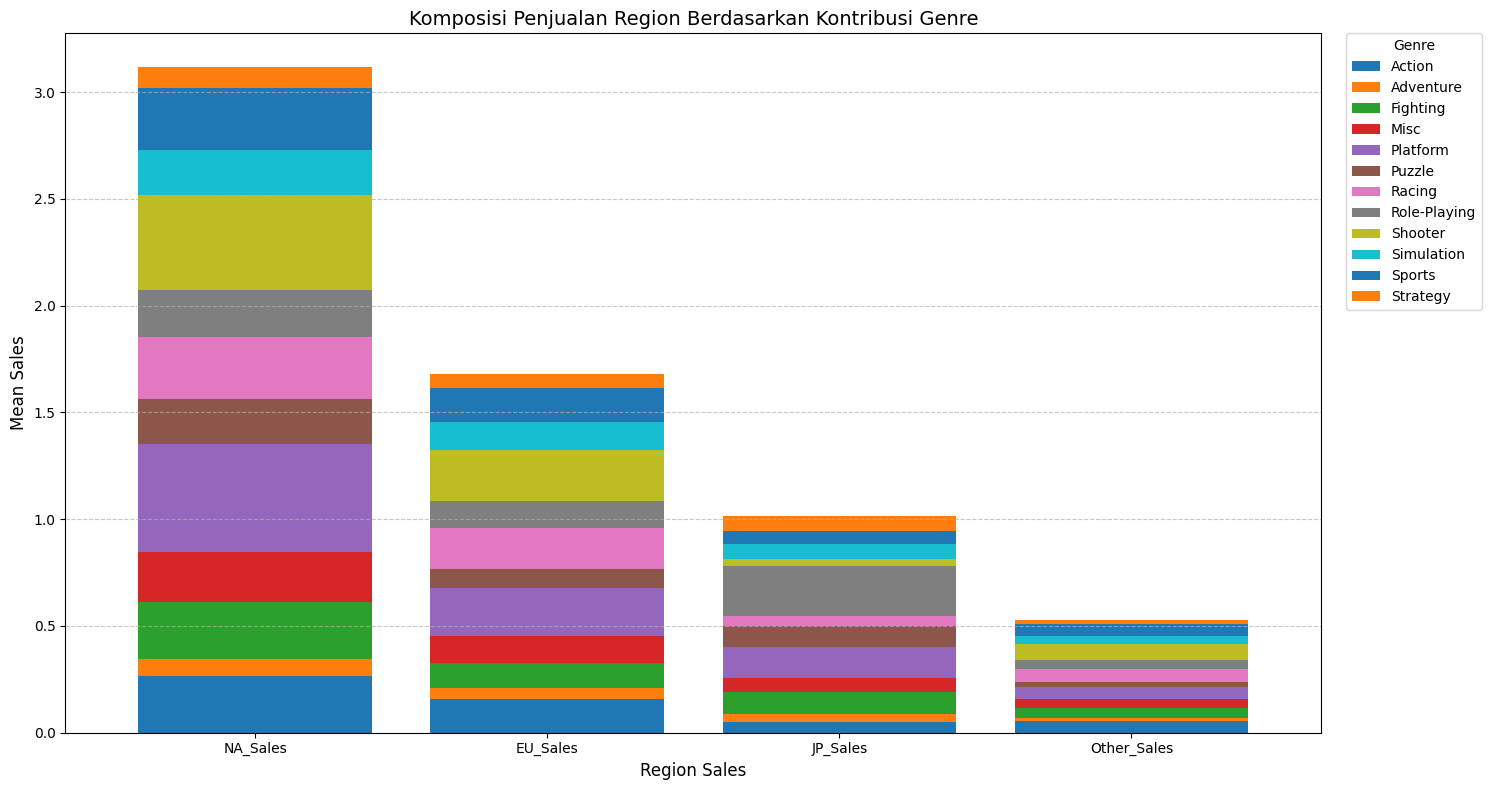

In [11]:
# Visualisasi Stack Barplot: x=Region, y=Mean_Sales, stacked by Genre

df_pivot = df_melted.pivot(index='Region', columns='Genre', values='Mean_Sales')

order_region_stack = df_pivot.sum(axis=1).sort_values(ascending=False).index
df_pivot_sorted = df_pivot.loc[order_region_stack]

ax = df_pivot_sorted.plot(kind='bar', stacked=True, figsize=(15, 8), width=0.8)

plt.title('Komposisi Penjualan Region Berdasarkan Kontribusi Genre', fontsize=14)
plt.xlabel('Region Sales', fontsize=12)
plt.ylabel('Mean Sales', fontsize=12)

plt.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Expected Output:

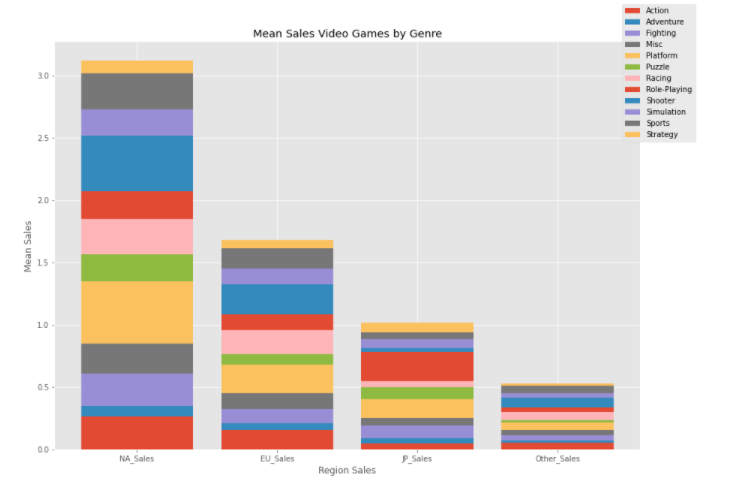

Kesimpulan :  
1. Secara keseluruhan, wilayah Amerika Utara (NA_Sales) memberikan kontribusi terbesar terhadap total rata-rata penjualan video game global untuk setiap genre.
2. Wilayah Eropa (EU_Sales) menempati posisi kedua dalam kontribusi penjualan di sebagian besar genre.
3. Meskipun secara total lebih rendah dari NA dan EU, wilayah Jepang memiliki pangsa pasar yang signifikan pada genre tertentu seperti Role-Playing dan Platform.
4. Penjualan di wilayah lain (Other_Sales) memberikan kontribusi paling kecil namun tetap stabil di seluruh genre.